### *1. Ising chain*

ED                  time=0.890s    E_0/L=-1.27528715
basis0    5         time=0.338s    E_0/L=-1.30960650   status=optimal 
basis1    13        time=0.627s    E_0/L=-1.28218055   status=optimal 
basis2    25        time=1.261s    E_0/L=-1.27945873   status=optimal 
basis3    49        time=5.383s    E_0/L=-1.27670704   status=optimal 
basis4    130       time=127.662s  E_0/L=-1.27543212   status=optimal 


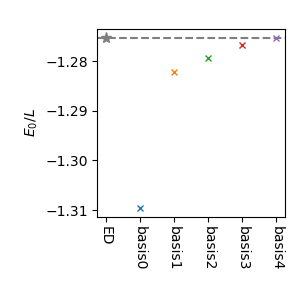

In [1]:
%reset -f
from ed.ising import IsingED
from compiler.ising import IsingParams, IsingCompiler, build_basis_reprs
from sdp import SDPSolver

import time
import matplotlib.pyplot as plt
%matplotlib widget

def ed_gs(L, J, h, hz):
    return IsingED(L=L, J=J, h=h, hz=hz).solve(vec=False)

def bootstrap_gs(L, J, h, hz, basis, eps=1e-4, max_iters=5_000):
    compiler = IsingCompiler(IsingParams(L=L, J=J, h=h, hz=hz))
    compiler.compile(build_basis_reprs(L, basis))
    solver = SDPSolver()
    solver.build(compiler.sdp_data())
    value = solver.solve(backend='SCS', eps=eps, max_iters=max_iters)
    return value, compiler.summary(), solver.summary()


L = 16
J = 1.
h = 1.
hz = 0.

basis0 = ['I', 'X', 'Y', 'Z', 'ZZ']
basis1 = basis0 + ['XX', 'YY', 'XZ', 'XY', 'YX', 'YZ', 'ZX', 'ZY']
basis2 = basis1 + ['X'+b+c for b in 'XYZI' for c in 'XYZ']
basis3 = basis1 + [a+b+c for a in 'XYZ' for b in 'XYZI' for c in 'XYZ']
basis4 = basis3 + [a+b+c+d for a in 'XYZ' for b in 'XYZ' for c in 'XYZ' for d in 'XYZ']
bases = {
    'basis0': basis0,
    'basis1': basis1,
    'basis2': basis2,
    'basis3': basis3,
    'basis4': basis4,
}
eps = 1e-4
max_iters = 5_000

fig, ax = plt.subplots(1, 1, figsize=(3,3))

t0 = time.perf_counter()
e0 = ed_gs(L, J=J, h=h, hz=hz)
dt = time.perf_counter() - t0
print(
    f'{"ED":<10s}'
    f'{"":<10s}'
    f'{f"time={dt:.3f}s":<15s}'
    f'{f"E_0/L={e0:.8f}":<15s}'
)
ax.plot(['ED'], [e0], marker='*', markersize=8, color='tab:grey')
ax.axhline(y=e0, color='tab:grey', linestyle='dashed')

for name, basis in bases.items():
    print(
        f'{name:<10s}'
        f'{len(basis):<10d}',
        end=''
    )
    t0 = time.perf_counter()
    e0_lower, compiler_summary, solver_summary = bootstrap_gs(
        L, J, h, hz, basis, eps=eps, max_iters=max_iters,
    )
    dt = time.perf_counter() - t0
    print(
        f'{f"time={dt:.3f}s":<15s}'
        f'{f"E_0/L={e0_lower:.8f}":<20s}'
        f'{"status=" + solver_summary["status"]:<15s}'
    )
    ax.plot([name], [e0_lower], marker='x', markersize=5, markerfacecolor='none')

ax.tick_params(axis='x', labelrotation=270)
ax.set_ylabel(r'$E_0/L$')

ax.set_box_aspect(1)
fig.tight_layout()

### *2. Hubbard chain*

ED                  time=0.548s    E_0/L=-1.58343226
d4s1r0    16        time=0.149s    E_0/L=-1.67828137   status=optimal 
d2s2r1    27        time=0.212s    E_0/L=-1.68884413   status=optimal 
d2s2r2    43        time=0.650s    E_0/L=-1.67284723   status=optimal 
d2s2r3    59        time=0.910s    E_0/L=-1.64149434   status=optimal 
d2s2r4    75        time=1.354s    E_0/L=-1.63280512   status=optimal 
d2s2r5    85        time=1.469s    E_0/L=-1.62938456   status=optimal 
d3s2r1    79        time=1.997s    E_0/L=-1.61259737   status=optimal 
d3s2r2    143       time=16.557s   E_0/L=-1.59981422   status=optimal 
d3s2r3    207       time=113.157s  E_0/L=-1.59436344   status=optimal 


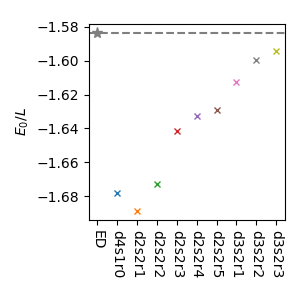

In [2]:
%reset -f
from ed.hubbard import HubbardED
from compiler.hubbard import HubbardParams, HubbardCompiler, build_basis_reprs
from sdp import SDPSolver

import time
import matplotlib.pyplot as plt
%matplotlib widget

def ed_gs(L, t, U, n_particles):
    assert n_particles % 2 == 0
    return HubbardED(L=L, t=t, U=U, Nf=(n_particles//2, n_particles//2)).solve(vec=False)

def bootstrap_gs(params, basis_reprs, eps=1e-4, max_iters=5_000):
    compiler = HubbardCompiler(params)
    compiler.compile(basis_reprs)
    solver = SDPSolver()
    solver.build(compiler.sdp_data())
    value = solver.solve(backend='SCS', eps=eps, max_iters=max_iters)
    return value, compiler.summary(), solver.summary()


L = 10
t = 1.
U = 4.
n_particles = L
params = HubbardParams(L=L, t=t, U=U, n_particles=n_particles)

bases = {
    'd4s1r0': build_basis_reprs(L, max_degree=4, max_support=1, max_diameter=0),
    'd2s2r1': build_basis_reprs(L, max_degree=2, max_support=2, max_diameter=1),
    'd2s2r2': build_basis_reprs(L, max_degree=2, max_support=2, max_diameter=2),
    'd2s2r3': build_basis_reprs(L, max_degree=2, max_support=2, max_diameter=3),
    'd2s2r4': build_basis_reprs(L, max_degree=2, max_support=2, max_diameter=4),
    'd2s2r5': build_basis_reprs(L, max_degree=2, max_support=2, max_diameter=5),
    'd3s2r1': build_basis_reprs(L, max_degree=3, max_support=2, max_diameter=1),
    'd3s2r2': build_basis_reprs(L, max_degree=3, max_support=2, max_diameter=2),
    'd3s2r3': build_basis_reprs(L, max_degree=3, max_support=2, max_diameter=3),
}
eps = 1e-4
max_iters = 5_000

fig, ax = plt.subplots(1, 1, figsize=(3,3))

t0 = time.perf_counter()
e0 = ed_gs(L, t=t, U=U, n_particles=n_particles)
dt = time.perf_counter() - t0
print(
    f'{"ED":<10s}'
    f'{"":<10s}'
    f'{f"time={dt:.3f}s":<15s}'
    f'{f"E_0/L={e0:.8f}":<15s}'
)
ax.plot(['ED'], [e0], marker='*', markersize=8, color='tab:grey')
ax.axhline(y=e0, color='tab:grey', linestyle='dashed')

for name, basis_reprs in bases.items():
    print(
        f'{name:<10s}'
        f'{len(basis_reprs):<10d}',
        end=''
    )
    t0 = time.perf_counter()
    e0_lower, compiler_summary, solver_summary = bootstrap_gs(
        params, basis_reprs, eps=eps, max_iters=max_iters,
    )
    dt = time.perf_counter() - t0
    print(
        f'{f"time={dt:.3f}s":<15s}'
        f'{f"E_0/L={e0_lower:.8f}":<20s}'
        f'{"status=" + solver_summary["status"]:<15s}'
    )
    ax.plot([name], [e0_lower], marker='x', markersize=5, markerfacecolor='none')

ax.tick_params(axis='x', labelrotation=270)
ax.set_ylabel(r'$E_0/L$')

ax.set_box_aspect(1)
fig.tight_layout()